<a href="https://colab.research.google.com/github/tololojo/AML_FinalProject/blob/lorenz_dataclass/ddcolor.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install modelscope
!pip install opencv-python-headless
!pip install addict
!pip install datasets
!pip install oss2
!pip install simplejson
!pip install timm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.3/41.3 kB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.7/5.7 MB 55.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 547.8/547.8 kB 13.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 116.3/116.3 kB 7.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 316.1/316.1 kB 18.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 39.9/39.9 MB 15.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.9/64.9 kB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 134.8/134.8 kB 11.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 194.1/194.1 kB 14.2 MB/s eta 0:00:00
  Attempting uninstall: requests
    Found existing installation: requests 2.31.0
    Uninstalling requests-2.31.0:
      Successfully uninstalled requests-2.31.0
  Attempting uninstall: pyarrow
    Found existing installation: pyarrow 14.0.2
    Uninstalling pyarrow-14.0.2:
      

# Inferencing on pretrained model

In [12]:
import cv2
from modelscope.outputs import OutputKeys
from modelscope.pipelines import pipeline
from modelscope.utils.constant import Tasks
import matplotlib.pyplot as plt
import requests
from PIL import Image
from io import BytesIO


img_colorization = pipeline(Tasks.image_colorization,
                       model='damo/cv_ddcolor_image-colorization')

2024-08-05 13:48:47,644 - modelscope - WARNING - Model revision not specified, use revision: v1.02
2024-08-05 13:48:47,910 - modelscope - INFO - initiate model from /root/.cache/modelscope/hub/damo/cv_ddcolor_image-colorization
2024-08-05 13:48:47,913 - modelscope - INFO - initiate model from location /root/.cache/modelscope/hub/damo/cv_ddcolor_image-colorization.
2024-08-05 13:48:47,919 - modelscope - INFO - initialize model from /root/.cache/modelscope/hub/damo/cv_ddcolor_image-colorization
2024-08-05 13:49:19,762 - modelscope - INFO - Loading DDColor model from /root/.cache/modelscope/hub/damo/cv_ddcolor_image-colorization/pytorch_model.pt, with param key: [params].
2024-08-05 13:49:20,662 - modelscope - INFO - load model done.
2024-08-05 13:49:20,724 - modelscope - WARNING - No preprocessor field found in cfg.
2024-08-05 13:49:20,726 - modelscope - WARNING - No val key and type key found in preprocessor domain of configuration.json file.
2024-08-05 13:49:20,728 - modelscope - WARNI

In [13]:
#img_path = 'https://wmts.geo.admin.ch/1.0.0/ch.swisstopo.swissimage-product/default/1979/2056/25/706/586.jpeg'
img_path = 'https://wmts.geo.admin.ch/1.0.0/ch.swisstopo.swissimage-product/default/1979/2056/20/88/78.jpeg'
result = img_colorization(img_path)
cv2.imwrite('result.png', result[OutputKeys.OUTPUT_IMG])

True

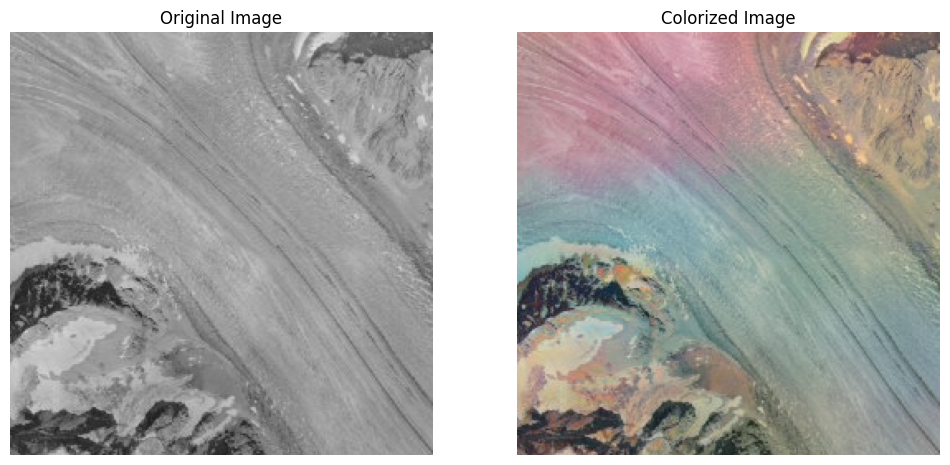

In [14]:
# Display the original and colorized images
# Fetch the original image
response = requests.get(img_path)
original_img = Image.open(BytesIO(response.content))

# Load the colorized image
colorized_img = Image.open('result.png')

# Plot the images
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

# Display original image
axes[0].imshow(original_img)
axes[0].set_title("Original Image")
axes[0].axis('off')

# Display colorized image
axes[1].imshow(colorized_img)
axes[1].set_title("Colorized Image")
axes[1].axis('off')

plt.show()

# Fine tuning

In [1]:
import requests
from bs4 import BeautifulSoup

def get_image_urls(base_url):
    response = requests.get(base_url)
    soup = BeautifulSoup(response.content, 'html.parser')
    image_urls = [base_url + '/' + node.get('href') for node in soup.find_all('a') if node.get('href').endswith('.jpg')]
    return image_urls

base_url = "https://perritos.myasustor.com:1986/data"
image_urls = get_image_urls(base_url)


In [2]:
import random

# Shuffle the image URLs
random.shuffle(image_urls)

# Split into training and validation sets (e.g., 80% train, 20% validation)
split_ratio = 0.8
split_index = int(len(image_urls) * split_ratio)
train_urls = image_urls[:split_index]
val_urls = image_urls[split_index:]


In [3]:
import os
import torch
from torch.utils.data import Dataset, DataLoader
import pickle

class CustomColorizationDataset(Dataset):
    def __init__(self, preprocessed_data_paths):
        self.data_paths = preprocessed_data_paths
        self.data = []
        for path in self.data_paths:
            with open(path, 'rb') as f:
                self.data.extend(pickle.load(f))

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        sample = self.data[idx]
        l_channel = torch.tensor(sample['l_channel'], dtype=torch.float32).unsqueeze(0)  # Add channel dimension
        return l_channel

# Function to create DataLoader
def create_dataloader(preprocessed_data_paths, batch_size=32):
    dataset = CustomColorizationDataset(preprocessed_data_paths)
    dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True, num_workers=2)
    return dataloader


In [5]:
import os
import tempfile
import logging
import random
import pickle
import requests
from bs4 import BeautifulSoup
from concurrent.futures import ThreadPoolExecutor, as_completed
from tqdm import tqdm
from PIL import Image
from io import BytesIO
import numpy as np
from skimage import color

# Set up logging
logging.basicConfig(level=logging.INFO)
logger = logging.getLogger(__name__)

def create_temp_dir():
    tmp_dir = tempfile.mkdtemp()
    logger.info(f"Temporary directory created at {tmp_dir}")
    return tmp_dir

def get_image_urls(base_url):
    response = requests.get(base_url)
    soup = BeautifulSoup(response.content, 'html.parser')
    image_urls = [base_url + '/' + node.get('href') for node in soup.find_all('a') if node.get('href').endswith('.jpg')]
    return image_urls

def fetch_image_from_url(url):
    response = requests.get(url)
    image = Image.open(BytesIO(response.content)).convert('RGB')
    return np.array(image)

def rgb_to_lab_l_channel(image):
    """Convert an RGB image to Lab color space and extract the L channel using skimage."""
    lab_image = color.rgb2lab(image)
    l_channel = lab_image[..., 0]  # Extract L channel
    return l_channel

def preprocess_single_url(url):
    """Preprocess a single URL to extract the L channel."""
    try:
        image = fetch_image_from_url(url)
        l_channel = rgb_to_lab_l_channel(image)
        return {'l_channel': l_channel}
    except Exception as e:
        logger.error(f"Failed to process image at {url}: {e}")
        return None

def preprocess_urls_in_batches(urls, batch_size=50, max_workers=16):
    """Preprocess images from URLs in batches to manage memory usage."""
    num_batches = (len(urls) + batch_size - 1) // batch_size
    preprocessed_data_paths = []

    for i in range(num_batches):
        batch_urls = urls[i * batch_size : (i + 1) * batch_size]
        preprocessed_batch = []

        with ThreadPoolExecutor(max_workers=max_workers) as executor:
            future_to_url = {executor.submit(preprocess_single_url, url): url for url in batch_urls}
            for future in tqdm(as_completed(future_to_url), total=len(batch_urls), desc=f"Preprocessing batch {i + 1}/{num_batches}"):
                result = future.result()
                if result is not None:
                    preprocessed_batch.append(result)

        batch_file = f"preprocessed_batch_{i + 1}.pkl"
        with open(batch_file, 'wb') as f:
            pickle.dump(preprocessed_batch, f)
        preprocessed_data_paths.append(batch_file)
        logger.info(f"Saved batch {i + 1} to {batch_file}")

    return preprocessed_data_paths

# Run preprocessing
def main_preprocess():
    tmp_dir = create_temp_dir()

    try:
        logger.info("Retrieving image URLs")
        base_url = "https://perritos.myasustor.com:1986/data"
        image_urls = get_image_urls(base_url)

        logger.info("Shuffling and splitting dataset")
        random.shuffle(image_urls)
        split_ratio = 0.8
        split_index = int(len(image_urls) * split_ratio)
        train_urls = image_urls[:split_index]
        val_urls = image_urls[split_index:]

        logger.info("Preprocessing training dataset")
        preprocessed_train_paths = preprocess_urls_in_batches(train_urls, batch_size=50, max_workers=16)

        logger.info("Preprocessing validation dataset")
        preprocessed_val_paths = preprocess_urls_in_batches(val_urls, batch_size=50, max_workers=16)

        # Save paths to preprocessed data
        with open('preprocessed_train_paths.pkl', 'wb') as f:
            pickle.dump(preprocessed_train_paths, f)
        with open('preprocessed_val_paths.pkl', 'wb') as f:
            pickle.dump(preprocessed_val_paths, f)

        logger.info("Preprocessing completed and data paths saved")

    except Exception as e:
        logger.error(f"An error occurred: {e}")
    finally:
        logger.info(f"Cleaning up temporary directory: {tmp_dir}")
        os.rmdir(tmp_dir)

if __name__ == "__main__":
    main_preprocess()


Preprocessing batch 52/52: 100%|██████████| 42/42 [00:02<00:00, 19.81it/s]


In [ ]:
import os
import shutil
import pickle
import logging
import tempfile
import traceback
from modelscope.trainers import build_trainer
from modelscope.utils.config import Config
from modelscope.utils.constant import ModelFile
from torch.utils.data import Dataset, DataLoader
import torch
from tqdm import tqdm

class CustomColorizationDataset(Dataset):
    def __init__(self, preprocessed_data_paths):
        self.data_paths = preprocessed_data_paths
        self.data = []
        for path in self.data_paths:
            with open(path, 'rb') as f:
                self.data.extend(pickle.load(f))

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        sample = self.data[idx]
        l_channel = torch.tensor(sample['l_channel'], dtype=torch.float32).unsqueeze(0)  # Add channel dimension
        return l_channel

def create_dataloader(preprocessed_data_paths, batch_size=32):
    dataset = CustomColorizationDataset(preprocessed_data_paths)
    dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True, num_workers=2)
    return dataloader

# Set up logging
logging.basicConfig(level=logging.INFO)
logger = logging.getLogger(__name__)

def create_temp_dir():
    tmp_dir = tempfile.mkdtemp()
    logger.info(f"Temporary directory created at {tmp_dir}")
    return tmp_dir

def main_train():
    tmp_dir = create_temp_dir()

    try:
        model_id = 'damo/cv_ddcolor_image-colorization'
        logger.info(f"Downloading model: {model_id}")
        cache_path = snapshot_download(model_id)
        config = Config.from_file(os.path.join(cache_path, ModelFile.CONFIGURATION))
        logger.info("Model configuration loaded")

        logger.info("Loading preprocessed data paths")
        with open('preprocessed_train_paths.pkl', 'rb') as f:
            preprocessed_train_paths = pickle.load(f)
        with open('preprocessed_val_paths.pkl', 'rb') as f:
            preprocessed_val_paths = pickle.load(f)

        logger.info("Creating DataLoaders for training and validation")
        train_loader = create_dataloader(preprocessed_train_paths, batch_size=32)
        val_loader = create_dataloader(preprocessed_val_paths, batch_size=32)

        logger.info("Building trainer")
        kwargs = dict(
            model=model_id,
            train_dataloader=train_loader,
            eval_dataloader=val_loader,
            work_dir=tmp_dir)

        trainer = build_trainer(default_args=kwargs)

        # Custom training loop with tqdm
        num_epochs = 2  # Set the number of epochs for training
        for epoch in range(num_epochs):
            logger.info(f"Epoch {epoch+1}/{num_epochs}")
            trainer.model.train()
            train_loss = 0
            for batch in tqdm(train_loader, desc=f"Training Epoch {epoch+1}"):
                loss = trainer.train_step(batch)
                train_loss += loss
            train_loss /= len(train_loader)

            trainer.model.eval()
            val_loss = 0
            for batch in tqdm(val_loader, desc=f"Validation Epoch {epoch+1}"):
                loss = trainer.eval_step(batch)
                val_loss += loss
            val_loss /= len(val_loader)

            logger.info(f"Epoch {epoch+1} completed. Training loss: {train_loss:.4f}, Validation loss: {val_loss:.4f}")

    except Exception as e:
        logger.error(f"An error occurred: {e}")
        traceback.print_exc()
    finally:
        logger.info(f"Cleaning up temporary directory: {tmp_dir}")
        shutil.rmtree(tmp_dir)  # Use shutil.rmtree to remove non-empty directories

if __name__ == "__main__":
    main_train()


2024-08-05 14:50:00,248 - modelscope - WARNING - Model revision not specified, use revision: v1.02


In [10]:
import os
import tempfile
import logging
from PIL import Image
import numpy as np
from skimage import color
from modelscope.hub.snapshot_download import snapshot_download
from modelscope.msdatasets import MsDataset
from modelscope.msdatasets.dataset_cls.custom_datasets.image_colorization import ImageColorizationDataset
from modelscope.trainers import build_trainer
from modelscope.utils.config import Config
from modelscope.utils.constant import DownloadMode, ModelFile

# Set up logging
logging.basicConfig(level=logging.INFO)
logger = logging.getLogger(__name__)

def create_temp_dir():
    tmp_dir = tempfile.mkdtemp()
    logger.info(f"Temporary directory created at {tmp_dir}")
    return tmp_dir

def rgb_to_lab_l_channel(image):
    """Convert an RGB image to Lab color space and extract the L channel."""
    lab_image = color.rgb2lab(image)
    l_channel = lab_image[:, :, 0]  # Extract L channel
    return l_channel

def preprocess_dataset(dataset):
    """Apply preprocessing to the dataset to convert images to grayscale using L channel."""
    def preprocess_function(example):
        image_path = example.get('Image:FILE')
        if not image_path:
            logger.error(f"Key 'Image:FILE' not found in example: {example.keys()}")
            raise KeyError("Key 'Image:FILE' not found in example")

        image = Image.open(image_path).convert('RGB')
        image = np.array(image)
        l_channel = rgb_to_lab_l_channel(image)
        example['l_channel'] = l_channel
        return example

    dataset = dataset.map(preprocess_function, num_proc=4)  # Use multiprocessing for efficiency
    return dataset

def main():
    tmp_dir = create_temp_dir()

    try:
        model_id = 'damo/cv_ddcolor_image-colorization'
        logger.info(f"Downloading model: {model_id}")
        cache_path = snapshot_download(model_id)
        config = Config.from_file(os.path.join(cache_path, ModelFile.CONFIGURATION))
        logger.info("Model configuration loaded")

        dataset_train = MsDataset.load(
            'imagenet-val5k-image',
            namespace='damo',
            subset_name='default',
            split='validation',
            download_mode=DownloadMode.REUSE_DATASET_IF_EXISTS)._hf_ds
        dataset_val = MsDataset.load(
            'imagenet-val5k-image',
            namespace='damo',
            subset_name='default',
            split='validation',
            download_mode=DownloadMode.REUSE_DATASET_IF_EXISTS)._hf_ds
        logger.info("Datasets loaded")

        # Debug: Print a few examples from the dataset to understand its structure
        logger.info(f"Example from training dataset: {dataset_train[0]}")
        logger.info(f"Example from validation dataset: {dataset_val[0]}")

        dataset_train = preprocess_dataset(dataset_train)
        dataset_val = preprocess_dataset(dataset_val)
        logger.info("Datasets preprocessed to extract L channel")

        dataset_train = ImageColorizationDataset(dataset_train, config.dataset, is_train=True)
        dataset_val = ImageColorizationDataset(dataset_val, config.dataset, is_train=False)
        logger.info("Datasets wrapped for colorization")

        kwargs = dict(
            model=model_id,
            train_dataset=dataset_train,
            eval_dataset=dataset_val,
            work_dir=tmp_dir)

        logger.info("Building trainer")
        trainer = build_trainer(default_args=kwargs)
        logger.info("Starting training")
        trainer.train()

    except Exception as e:
        logger.error(f"An error occurred: {e}")
    finally:
        logger.info(f"Cleaning up temporary directory: {tmp_dir}")
        os.rmdir(tmp_dir)

if __name__ == "__main__":
    main()


2024-08-05 13:45:55,690 - modelscope - WARNING - Model revision not specified, use revision: v1.02
2024-08-05 13:45:58,799 - modelscope - WARNING - Reusing dataset dataset_builder (/root/.cache/modelscope/hub/datasets/damo/imagenet-val5k-image/master/data_files)
2024-08-05 13:45:58,806 - modelscope - INFO - Generating dataset dataset_builder (/root/.cache/modelscope/hub/datasets/damo/imagenet-val5k-image/master/data_files)
2024-08-05 13:45:58,813 - modelscope - INFO - Reusing cached meta-data file: /root/.cache/modelscope/hub/datasets/damo/imagenet-val5k-image/master/data_files/9cc4162cf3f05d92f6d1fe5d95bc946c
2024-08-05 13:46:03,807 - modelscope - WARNING - Reusing dataset dataset_builder (/root/.cache/modelscope/hub/datasets/damo/imagenet-val5k-image/master/data_files)
2024-08-05 13:46:03,809 - modelscope - INFO - Generating dataset dataset_builder (/root/.cache/modelscope/hub/datasets/damo/imagenet-val5k-image/master/data_files)
2024-08-05 13:46:03,814 - modelscope - INFO - Reusing 

Map (num_proc=4):   0%|          | 0/5000 [00:00<?, ? examples/s]

ERROR:__main__:An error occurred: One of the subprocesses has abruptly died during map operation.To debug the error, disable multiprocessing.
